# Day 16 — Standalone Notebook

This notebook skips re-running **Day 15's baseline training** (the long `model.train()` call).
It only rebuilds the data (fast — no training) so `data.yaml` exists in this fresh runtime, then goes straight into **Day 16** training/comparison.

**Assumption:** your Day 15 run (`best.pt`, `last.pt`, `results.csv`) is already saved in Drive at
`/content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day15_yolov8n_baseline/`. If it isn't there, the Day 16.5 cell below will fail with a clear "file not found" message telling you Day 15 needs to be run first.


## Setup — rebuild the dataset only (no training)
This reproduces just what Day 16 needs: `material_path`, `train_data`/`val_data`, `categories`, `garbage_ids`, and the finished `Dataset V1` folder + `data.yaml`. It does **not** re-run Day 15's `model.train()`.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/INTERNSHIPWORK/dataset.zip'
extract_path = '/content/TrashCAN'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [3]:
dataset_path = '/content/TrashCAN/dataset'
material_path = os.path.join(dataset_path, 'material_version')

print("Material version contents:")
for item in os.listdir(material_path):
    print(item)

Material version contents:
train
README.txt
instances_train_trashcan.json
val
instances_val_trashcan.json


In [4]:
train_path = os.path.join(material_path, 'train')
val_path = os.path.join(material_path, 'val')

image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

train_images = [
    f for f in os.listdir(train_path)
    if f.lower().endswith(image_extensions)
]

val_images = [
    f for f in os.listdir(val_path)
    if f.lower().endswith(image_extensions)
]

print("===== DATASET IMAGE COUNT =====")
print("Training images   :", len(train_images))
print("Validation images :", len(val_images))
print("Total images      :", len(train_images) + len(val_images))

===== DATASET IMAGE COUNT =====
Training images   : 6008
Validation images : 1204
Total images      : 7212


In [5]:
import json

train_json_path = os.path.join(material_path, 'instances_train_trashcan.json')
val_json_path = os.path.join(material_path, 'instances_val_trashcan.json')

with open(train_json_path, 'r') as f:
    train_data = json.load(f)

with open(val_json_path, 'r') as f:
    val_data = json.load(f)

print("===== COCO DATASET INFORMATION =====")
print("\nTRAINING")
print("Images       :", len(train_data['images']))
print("Annotations  :", len(train_data['annotations']))
print("Categories   :", len(train_data['categories']))

print("\nVALIDATION")
print("Images       :", len(val_data['images']))
print("Annotations  :", len(val_data['annotations']))
print("Categories   :", len(val_data['categories']))

===== COCO DATASET INFORMATION =====

TRAINING
Images       : 6008
Annotations  : 9741
Categories   : 16

VALIDATION
Images       : 1204
Annotations  : 2595
Categories   : 16


In [6]:
categories = train_data['categories']

for cat in categories:
    print(cat['id'], "→", cat['name'])

1 → rov
2 → plant
3 → animal_fish
4 → animal_starfish
5 → animal_shells
6 → animal_crab
7 → animal_eel
8 → animal_etc
9 → trash_etc
10 → trash_fabric
11 → trash_fishing_gear
12 → trash_metal
13 → trash_paper
14 → trash_plastic
15 → trash_rubber
16 → trash_wood


In [7]:
category_names = {cat['id']: cat['name'] for cat in categories}

garbage_classes = [c['name'] for c in categories if c['name'].startswith('trash_')]
non_garbage_classes = [c['name'] for c in categories if not c['name'].startswith('trash_')]

print("Garbage classes (", len(garbage_classes), "):", garbage_classes)
print("Non-garbage classes (", len(non_garbage_classes), "):", non_garbage_classes)

Garbage classes ( 8 ): ['trash_etc', 'trash_fabric', 'trash_fishing_gear', 'trash_metal', 'trash_paper', 'trash_plastic', 'trash_rubber', 'trash_wood']
Non-garbage classes ( 8 ): ['rov', 'plant', 'animal_fish', 'animal_starfish', 'animal_shells', 'animal_crab', 'animal_eel', 'animal_etc']


In [9]:
garbage_ids = {c['id'] for c in categories if c['name'].startswith('trash_')}

garbage_counts = Counter(
    ann['category_id'] for ann in train_data['annotations']
    if ann['category_id'] in garbage_ids
)

print("Garbage-only class distribution:\n")
for cid, count in garbage_counts.most_common():
    print(category_names[cid], "→", count)

Garbage-only class distribution:

trash_etc → 1630
trash_plastic → 1490
trash_metal → 901
trash_wood → 271
trash_fabric → 247
trash_paper → 154
trash_fishing_gear → 127
trash_rubber → 113


In [8]:
# Reuse variables created in the Day 2 section:
# material_path, train_path, val_path, train_data, val_data, categories, category_names

import os
import json
import random
import hashlib
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

def list_images(folder):
    return sorted(
        f for f in os.listdir(folder)
        if f.lower().endswith(image_extensions)
    )

train_images = list_images(train_path)
val_images = list_images(val_path)

print("===== DAY 10 DATASET CHECK =====")
print("Material-version train images:", len(train_images))
print("Material-version val images  :", len(val_images))
print("Train JSON images            :", len(train_data["images"]))
print("Val JSON images              :", len(val_data["images"]))
print("Categories                   :", len(categories))
print("Random seed                  :", RANDOM_SEED)

assert len(train_images) == len(train_data["images"]), "Train image count mismatch."
assert len(val_images) == len(val_data["images"]), "Val image count mismatch."
print("Integrity check: PASS")


===== DAY 10 DATASET CHECK =====
Material-version train images: 6008
Material-version val images  : 1204
Train JSON images            : 6008
Val JSON images              : 1204
Categories                   : 16
Random seed                  : 42
Integrity check: PASS


### Rebuild Dataset V1 (Day 11 preprocessing — fast, not training)

In [10]:
# Install only the package needed for YOLO-format validation/training later.
!pip -q install ultralytics

import yaml
from shutil import copy2
from tqdm.auto import tqdm

print("YOLO/Ultralytics environment ready.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 9.5 MB/s eta 0:00:00
YOLO/Ultralytics environment ready.


In [11]:
# Keep the original material-version train/val pools separate.
# Correct split design:
#   source_train -> 80% train + 20% test
#   source_val   -> retained as val
# This preserves the dataset's original validation set instead of re-splitting it.
#
# Exact duplicate files are grouped by SHA-256 so identical file contents
# cannot be divided between train and test.

all_sources = [
    ("source_train", train_path, train_data),
    ("source_val", val_path, val_data)
]

image_records = []
json_lookup = {}

for source_name, folder, coco_data in all_sources:
    for img in coco_data["images"]:
        filename = os.path.basename(img["file_name"])
        image_path = os.path.join(folder, filename)

        if not os.path.isfile(image_path):
            raise FileNotFoundError(f"Image missing: {image_path}")

        json_lookup[(source_name, filename)] = img

        image_records.append({
            "source_pool": source_name,
            "filename": filename,
            "image_path": image_path,
            "width": int(img["width"]),
            "height": int(img["height"]),
            "image_id": int(img["id"])
        })

# Build annotation lookup by (source pool, image id).
annotation_lookup = defaultdict(list)

for source_name, _, coco_data in all_sources:
    for ann in coco_data["annotations"]:
        annotation_lookup[(source_name, int(ann["image_id"]))].append(ann)

def sha256_file(path, chunk_size=1024 * 1024):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

for record in tqdm(image_records, desc="Hashing images"):
    record["sha256"] = sha256_file(record["image_path"])

# Show exact duplicate groups.
hash_counts = Counter(r["sha256"] for r in image_records)
duplicate_groups = {h: c for h, c in hash_counts.items() if c > 1}

print("Total images indexed:", len(image_records))
print("Unique SHA-256 image contents:", len(hash_counts))
print("Exact-duplicate groups:", len(duplicate_groups))
print("Images belonging to duplicate groups:",
      sum(duplicate_groups.values()))

# Important limitation:
# SHA-256 catches exact duplicate files/content. The dataset metadata shown in
# the supplied COCO structure does not expose source-video IDs, so source-level
# leakage cannot be guaranteed from metadata alone.


Hashing images:   0%|          | 0/7212 [00:00<?, ?it/s]

Total images indexed: 7212
Unique SHA-256 image contents: 7212
Exact-duplicate groups: 0
Images belonging to duplicate groups: 0


In [15]:
from sklearn.model_selection import GroupShuffleSplit

records_df = pd.DataFrame(image_records)

source_train_df = records_df[records_df["source_pool"] == "source_train"].copy()
source_val_df = records_df[records_df["source_pool"] == "source_val"].copy()

# Corrected ratio:
# Original training pool -> 80% train + 20% test.
# Original validation pool -> retained unchanged as validation.
gss_test = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_SEED
)

train_idx, test_idx = next(
    gss_test.split(source_train_df, groups=source_train_df["sha256"])
)

train_df = source_train_df.iloc[train_idx].copy()
test_df = source_train_df.iloc[test_idx].copy()
val_df = source_val_df.copy()

train_df["split"] = "train"
val_df["split"] = "val"
test_df["split"] = "test"

split_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

print("===== FINAL SPLIT =====")
print(split_df["split"].value_counts())

print("\nFinal percentages across all 7212 images:")
print((split_df["split"].value_counts(normalize=True) * 100).round(2))

print("\nSource-pool split rule:")
print("Original train pool:", len(source_train_df), "images → 80% train + 20% test")
print("Original val pool  :", len(source_val_df), "images → retained as val")

# Verify no exact-content group crosses final splits.
hash_split_counts = split_df.groupby("sha256")["split"].nunique()
cross_split_hashes = hash_split_counts[hash_split_counts > 1]

print("\nExact duplicate hashes crossing final splits:", len(cross_split_hashes))
assert len(cross_split_hashes) == 0, "Leakage detected: duplicate content crosses splits."

print("Leakage check: PASS for exact duplicate content.")


===== FINAL SPLIT =====
split
train    4806
val      1204
test     1202
Name: count, dtype: int64

Final percentages across all 7212 images:
split
train    66.64
val      16.69
test     16.67
Name: proportion, dtype: float64

Source-pool split rule:
Original train pool: 6008 images → 80% train + 20% test
Original val pool  : 1204 images → retained as val

Exact duplicate hashes crossing final splits: 0
Leakage check: PASS for exact duplicate content.


In [12]:
# YOLO label format:
# class_id x_center y_center width height
# All box coordinates are normalized to [0, 1].

garbage_categories = [
    cat for cat in categories
    if cat["id"] in garbage_ids
]

# Stable class mapping: alphabetical order, independent of COCO IDs.
garbage_categories = sorted(garbage_categories, key=lambda x: x["name"])

yolo_class_map = {
    cat["id"]: idx
    for idx, cat in enumerate(garbage_categories)
}

yolo_names = {
    idx: cat["name"]
    for idx, cat in enumerate(garbage_categories)
}

print("YOLO class mapping:")
for idx in sorted(yolo_names):
    print(idx, "→", yolo_names[idx])

def coco_bbox_to_yolo(bbox, image_width, image_height):
    x, y, w, h = [float(v) for v in bbox]

    # Clip box to image boundaries for safety.
    x1 = max(0.0, min(x, image_width))
    y1 = max(0.0, min(y, image_height))
    x2 = max(0.0, min(x + w, image_width))
    y2 = max(0.0, min(y + h, image_height))

    clipped_w = x2 - x1
    clipped_h = y2 - y1

    if clipped_w <= 0 or clipped_h <= 0:
        return None

    x_center = (x1 + x2) / 2.0 / image_width
    y_center = (y1 + y2) / 2.0 / image_height
    norm_w = clipped_w / image_width
    norm_h = clipped_h / image_height

    values = [x_center, y_center, norm_w, norm_h]

    # Numerical safety.
    values = [min(1.0, max(0.0, v)) for v in values]
    return values

print("Bounding-box conversion function ready.")


YOLO class mapping:
0 → trash_etc
1 → trash_fabric
2 → trash_fishing_gear
3 → trash_metal
4 → trash_paper
5 → trash_plastic
6 → trash_rubber
7 → trash_wood
Bounding-box conversion function ready.


In [16]:
V1_ROOT = Path("/content/TrashCAN_YOLO_Dataset_V1")

if V1_ROOT.exists():
    # Remove only the generated V1 directory, never the source dataset.
    import shutil
    shutil.rmtree(V1_ROOT)

for split_name in ["train", "val", "test"]:
    (V1_ROOT / "images" / split_name).mkdir(parents=True, exist_ok=True)
    (V1_ROOT / "labels" / split_name).mkdir(parents=True, exist_ok=True)

# Helper to fetch the annotations for each image.
for _, row in tqdm(split_df.iterrows(), total=len(split_df), desc="Preparing Dataset V1"):
    split_name = row["split"]
    source_pool = row["source_pool"]
    image_id = int(row["image_id"])
    filename = row["filename"]
    image_width = int(row["width"])
    image_height = int(row["height"])

    destination_image = V1_ROOT / "images" / split_name / filename
    destination_label = V1_ROOT / "labels" / split_name / f"{Path(filename).stem}.txt"

    copy2(row["image_path"], destination_image)

    yolo_lines = []

    for ann in annotation_lookup[(source_pool, image_id)]:
        cid = int(ann["category_id"])

        # Dataset V1 targets garbage classes only.
        if cid not in yolo_class_map:
            continue

        yolo_box = coco_bbox_to_yolo(
            ann["bbox"],
            image_width,
            image_height
        )

        if yolo_box is None:
            continue

        class_id = yolo_class_map[cid]
        yolo_lines.append(
            str(class_id) + " " +
            " ".join(f"{v:.6f}" for v in yolo_box)
        )

    # Write an empty label file for background images if any exist.
    destination_label.write_text(
        "\n".join(yolo_lines),
        encoding="utf-8"
    )

print("Dataset V1 created at:", V1_ROOT)


Preparing Dataset V1:   0%|          | 0/7212 [00:00<?, ?it/s]

Dataset V1 created at: /content/TrashCAN_YOLO_Dataset_V1


In [17]:
validation_errors = []
label_counts = Counter()

for split_name in ["train", "val", "test"]:
    image_dir = V1_ROOT / "images" / split_name
    label_dir = V1_ROOT / "labels" / split_name

    image_files = sorted(
        p for p in image_dir.iterdir()
        if p.suffix.lower() in image_extensions
    )

    for image_path in image_files:
        label_path = label_dir / f"{image_path.stem}.txt"

        if not label_path.exists():
            validation_errors.append(f"Missing label file: {label_path}")
            continue

        lines = label_path.read_text(encoding="utf-8").strip().splitlines()

        for line_no, line in enumerate(lines, start=1):
            parts = line.split()

            if len(parts) != 5:
                validation_errors.append(
                    f"{label_path}:{line_no} has {len(parts)} fields; expected 5."
                )
                continue

            try:
                class_id = int(parts[0])
                values = [float(x) for x in parts[1:]]
            except ValueError:
                validation_errors.append(
                    f"{label_path}:{line_no} contains non-numeric values."
                )
                continue

            if not (0 <= class_id < len(yolo_names)):
                validation_errors.append(
                    f"{label_path}:{line_no} invalid class id {class_id}."
                )

            if any(v < 0 or v > 1 for v in values):
                validation_errors.append(
                    f"{label_path}:{line_no} coordinates outside [0,1]."
                )

            if values[2] <= 0 or values[3] <= 0:
                validation_errors.append(
                    f"{label_path}:{line_no} has non-positive width/height."
                )

            label_counts[split_name] += 1

print("YOLO label rows:")
for split_name in ["train", "val", "test"]:
    print(split_name, "→", label_counts[split_name])

print("Validation errors:", len(validation_errors))

if validation_errors:
    for error in validation_errors[:20]:
        print("ERROR:", error)
    raise ValueError("Dataset V1 label validation failed.")

print("YOLO label validation: PASS")


YOLO label rows:
train → 3947
val → 1281
test → 986
Validation errors: 0
YOLO label validation: PASS


In [18]:
data_yaml = {
    "path": str(V1_ROOT),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": [yolo_names[i] for i in range(len(yolo_names))]
}

yaml_path = V1_ROOT / "data.yaml"
with open(yaml_path, "w", encoding="utf-8") as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False, allow_unicode=True)

preprocessing_config = {
    "dataset_name": "TrashCAN 1.0",
    "source_version": "material_version",
    "target_task": "underwater garbage object detection",
    "target_classes": data_yaml["names"],
    "source_images_untouched": True,
    "training_image_size": 640,
    "resize_mode": "YOLO letterbox/resize at training time",
    "normalization": "handled by YOLO training pipeline",
    "split_seed": RANDOM_SEED,
    "split_strategy": "original material_version train pool split 80/20 into train/test; original material_version val pool retained as val",
    "split_definition": {
        "original_train_pool": {
            "source_images": int(len(source_train_df)),
            "train_ratio": 0.80,
            "test_ratio": 0.20
        },
        "original_val_pool": {
            "source_images": int(len(source_val_df)),
            "retained_as": "val"
        }
    },
    "augmentation_policy": {
        "mode": "on-the-fly",
        "enabled": True,
        "justification": "Use only augmentations supported by Day 10 observations; preview before final training.",
        "planned": [
            "horizontal flip when semantically valid",
            "limited brightness/contrast variation",
            "limited HSV/colour variation"
        ]
    }
}

config_path = V1_ROOT / "preprocessing_config.yaml"
with open(config_path, "w", encoding="utf-8") as f:
    yaml.safe_dump(preprocessing_config, f, sort_keys=False, allow_unicode=True)

split_path = V1_ROOT / "split_manifest.csv"
split_df.sort_values(["split", "filename"]).to_csv(split_path, index=False)

print("Saved:")
print("-", yaml_path)
print("-", config_path)
print("-", split_path)


Saved:
- /content/TrashCAN_YOLO_Dataset_V1/data.yaml
- /content/TrashCAN_YOLO_Dataset_V1/preprocessing_config.yaml
- /content/TrashCAN_YOLO_Dataset_V1/split_manifest.csv


---
## DAY 16 — starts here
(Day 15's training cell is intentionally skipped — its outputs are reused from Drive.)

In [19]:
# Day 16.1 — Reuse the exact Day 15 dataset configuration
from pathlib import Path
import pandas as pd
import numpy as np
import time
import yaml
from ultralytics import YOLO

DATA_YAML = "/content/TrashCAN_YOLO_Dataset_V1/data.yaml"
PROJECT_DIR = "/content/drive/MyDrive/INTERNSHIPWORK/yolo_runs"

assert Path(DATA_YAML).exists(), f"Dataset YAML not found: {DATA_YAML}"

with open(DATA_YAML, "r", encoding="utf-8") as f:
    data_config = yaml.safe_load(f)

class_names = data_config["names"]
print("Dataset:", DATA_YAML)
print("Classes:", class_names)
print("Number of classes:", len(class_names))

# These should match Day 15.
BASELINE_IMGSZ = 640
SECOND_IMGSZ = 832
EPOCHS_DAY16 = 100
print("Day 16 comparison: 640 vs 832")


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Dataset: /content/TrashCAN_YOLO_Dataset_V1/data.yaml
Classes: ['trash_etc', 'trash_fabric', 'trash_fishing_gear', 'trash_metal', 'trash_paper', 'trash_plastic', 'trash_rubber', 'trash_wood']
Number of classes: 8
Day 16 comparison: 640 vs 832


In [ ]:
# Day 16.2 — Train the second configuration
# Same YOLOv8n model and same Dataset V1; only image size changes.

model_day16 = YOLO("yolov8n.pt")

DAY16_RUN = "day16_yolov8n_img832"

results_day16 = model_day16.train(
    data=DATA_YAML,
    epochs=EPOCHS_DAY16,
    imgsz=SECOND_IMGSZ,
    project=PROJECT_DIR,
    name=DAY16_RUN,
    pretrained=True,
    plots=True,
    save=True,
    verbose=True
)

print("Day 16 training completed.")
print("Run directory:", Path(PROJECT_DIR) / DAY16_RUN)


Ultralytics 8.4.157 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/TrashCAN_YOLO_Dataset_V1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=832, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=day16_yolov8n_img832-28, nbs=64,

In [ ]:
!pip install ultralytics==8.4.155 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 7.5 MB/s eta 0:00:00


In [20]:
import ultralytics
print("Ultralytics version:", ultralytics.__version__)

Ultralytics version: 8.4.157


In [21]:
import os

root = "/content/drive/MyDrive/INTERNSHIPWORK/yolo_runs"

for folder in os.listdir(root):
    if "day16" in folder.lower():
        weights = os.path.join(root, folder, "weights")
        if os.path.exists(weights):
            print("\n📁", folder)
            for f in os.listdir(weights):
                if f.endswith(".pt"):
                    print("   ", f)


📁 day16_yolov8n_img832
    best.pt
    last.pt

📁 day16_yolov8n_img832-2

📁 day16_yolov8n_img832-3

📁 day16_yolov8n_img832-4

📁 day16_yolov8n_img832-5

📁 day16_yolov8n_img832-6

📁 day16_yolov8n_img832-7
    last.pt
    best.pt

📁 day16_yolov8n_img832-8
    best.pt
    last.pt

📁 day16_yolov8n_img832-9

📁 day16_yolov8n_img832-10

📁 day16_yolov8n_img832-11

📁 day16_yolov8n_img832-12

📁 day16_yolov8n_img832-13
    best.pt
    last.pt

📁 day16_yolov8n_img832-14

📁 day16_yolov8n_img832-15

📁 day16_yolov8n_img832-16

📁 day16_yolov8n_img832-17

📁 day16_yolov8n_img832-18

📁 day16_yolov8n_img832-19

📁 day16_yolov8n_img832-20

📁 day16_yolov8n_img832-21

📁 day16_yolov8n_img832-22
    last.pt
    best.pt

📁 day16_yolov8n_img832-23
    best.pt
    last.pt

📁 day16_yolov8n_img832-24

📁 day16_yolov8n_img832-25

📁 day16_yolov8n_img832-26
    last.pt
    best.pt

📁 day16_yolov8n_img832-27
    last.pt
    best.pt

📁 day16_yolov8n_img832-28
    best.pt
    last.pt


In [22]:
import os
import torch

root = "/content/drive/MyDrive/INTERNSHIPWORK/yolo_runs"

for folder in sorted(os.listdir(root)):
    if not folder.startswith("day16_yolov8n_img832"):
        continue

    last_path = os.path.join(root, folder, "weights", "last.pt")

    if os.path.exists(last_path):
        try:
            ckpt = torch.load(last_path, map_location="cpu", weights_only=False)

            epoch = ckpt.get("epoch", "unknown")

            print(f"{folder}  -->  last.pt epoch = {epoch + 1 if isinstance(epoch, int) else epoch}")

        except Exception as e:
            print(f"{folder}  --> ERROR: {e}")

day16_yolov8n_img832  -->  last.pt epoch = 36
day16_yolov8n_img832-13  -->  last.pt epoch = 69
day16_yolov8n_img832-22  -->  last.pt epoch = 1
day16_yolov8n_img832-23  -->  last.pt epoch = 37
day16_yolov8n_img832-26  -->  last.pt epoch = 1
day16_yolov8n_img832-27  -->  last.pt epoch = 1
day16_yolov8n_img832-28  -->  last.pt epoch = 59
day16_yolov8n_img832-7  -->  last.pt epoch = 25
day16_yolov8n_img832-8  -->  last.pt epoch = 41


In [23]:
from ultralytics import YOLO

RESUME_PATH = "/content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day16_yolov8n_img832-28/weights/last.pt"

model_day16 = YOLO(RESUME_PATH)

results = model_day16.train(resume=True)

Ultralytics 8.4.157 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/TrashCAN_YOLO_Dataset_V1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=832, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day16_yolov8n_img832-28/weights/last.pt, momen

In [24]:
# Day 16.3 — Validate the second configuration
metrics_day16 = model_day16.val(
    data=DATA_YAML,
    imgsz=SECOND_IMGSZ,
    plots=True
)

print("Day 16 validation completed.")


Ultralytics 8.4.157 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,007,208 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 894.2±338.0 MB/s, size: 22.6 KB)
val: Scanning /content/TrashCAN_YOLO_Dataset_V1/labels/val.cache... 1204 images, 214 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1204/1204 420.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 76/76 6.5it/s 11.7s
                   all       1204       1281      0.779      0.559      0.598       0.43
             trash_etc        301        409       0.61      0.513       0.49      0.301
          trash_fabric         56         67      0.794      0.672      0.729      0.543
    trash_fishing_gear         57         69      0.699      0.594      0.606      0.378
           trash_metal        214        225      0.819      0.573      0.633       0.45
           trash_paper     

In [25]:
# Day 16.4 — Class-wise comparison
day16_class_results = []

for class_id, class_name in enumerate(class_names):
    day16_class_results.append({
        "class": class_name,
        "precision": float(metrics_day16.box.p[class_id]),
        "recall": float(metrics_day16.box.r[class_id]),
        "mAP50": float(metrics_day16.box.ap50[class_id]),
        "mAP50-95": float(metrics_day16.box.ap[class_id]),
    })

day16_class_df = pd.DataFrame(day16_class_results)
display(day16_class_df)


,class,precision,recall,mAP50,mAP50-95
0,trash_etc,0.609518,0.513447,0.489749,0.301084
1,trash_fabric,0.794163,0.671642,0.728653,0.542655
2,trash_fishing_gear,0.699468,0.594203,0.606339,0.378322
3,trash_metal,0.818894,0.573333,0.632859,0.450027
4,trash_paper,0.726950,0.564103,0.550067,0.427244
5,trash_plastic,0.812684,0.639037,0.753031,0.553634
6,trash_rubber,1.000000,0.391912,0.423667,0.315417
7,trash_wood,0.769013,0.521739,0.599466,0.467893


In [32]:
# Day 16.5 — Load Day 15 and Day 16 summary metrics
# Read the actual saved results.csv files.
# No old numbers are entered manually.

from pathlib import Path
import pandas as pd
import numpy as np

# YOLO runs folder
PROJECT_DIR = Path("/content/drive/MyDrive/INTERNSHIPWORK/yolo_runs")

# ---------------------------------------------------------
# 1. Find Day 15 results.csv
# ---------------------------------------------------------

day15_candidates = list(
    PROJECT_DIR.glob("day15_yolov8n_baseline*/results.csv")
)

if not day15_candidates:
    raise FileNotFoundError(
        f"No Day 15 results.csv found inside:\n{PROJECT_DIR}"
    )

# ---------------------------------------------------------
# 2. Find all Day 16 results.csv files
# ---------------------------------------------------------

day16_candidates = list(
    PROJECT_DIR.glob("day16_yolov8n_img832*/results.csv")
)

if not day16_candidates:
    raise FileNotFoundError(
        f"No Day 16 results.csv found inside:\n{PROJECT_DIR}"
    )

print("Day 15 results found:")
for f in day15_candidates:
    print("  ", f)

print("\nDay 16 results found:")
for f in day16_candidates:
    print("  ", f)


# ---------------------------------------------------------
# 3. Select the run with the highest completed epoch
# ---------------------------------------------------------

def select_longest_run(csv_files):

    valid_runs = []

    for csv_file in csv_files:

        try:
            df = pd.read_csv(csv_file)

            if "epoch" not in df.columns:
                continue

            last_epoch = df["epoch"].max()

            valid_runs.append(
                (last_epoch, csv_file)
            )

        except Exception as e:
            print(f"Skipping {csv_file}: {e}")

    if not valid_runs:
        raise FileNotFoundError(
            "No valid results.csv files were found."
        )

    # Highest completed epoch
    valid_runs.sort(
        key=lambda x: x[0],
        reverse=True
    )

    return valid_runs[0][1]


# Select actual runs
day15_csv = select_longest_run(day15_candidates)
day16_csv = select_longest_run(day16_candidates)


# ---------------------------------------------------------
# 4. Show which runs were selected
# ---------------------------------------------------------

print("\n===================================")
print("SELECTED RUNS")
print("===================================")

print("\nDay 15:")
print(day15_csv)

print("\nDay 16:")
print(day16_csv)


# ---------------------------------------------------------
# 5. Read the actual CSV files
# ---------------------------------------------------------

r15 = pd.read_csv(day15_csv)
r16 = pd.read_csv(day16_csv)


print("\nDay 15 epochs:")
print(
    r15["epoch"].min(),
    "to",
    r15["epoch"].max()
)

print("\nDay 16 epochs:")
print(
    r16["epoch"].min(),
    "to",
    r16["epoch"].max()
)


# ---------------------------------------------------------
# 6. Create summary
# ---------------------------------------------------------

summary = pd.DataFrame([
    {
        "experiment": "Day 15 — YOLOv8n, 640",
        "imgsz": 640,

        "best_mAP50":
            r15["metrics/mAP50(B)"].max(),

        "best_mAP50-95":
            r15["metrics/mAP50-95(B)"].max(),

        "best_precision":
            r15["metrics/precision(B)"].max(),

        "best_recall":
            r15["metrics/recall(B)"].max(),
    },

    {
        "experiment": "Day 16 — YOLOv8n, 832",
        "imgsz": 832,

        "best_mAP50":
            r16["metrics/mAP50(B)"].max(),

        "best_mAP50-95":
            r16["metrics/mAP50-95(B)"].max(),

        "best_precision":
            r16["metrics/precision(B)"].max(),

        "best_recall":
            r16["metrics/recall(B)"].max(),
    }
])


# ---------------------------------------------------------
# 7. Display final comparison
# ---------------------------------------------------------

display(summary)

Day 15 results found:
   /content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day15_yolov8n_baseline-2/results.csv
   /content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day15_yolov8n_baseline-3/results.csv
   /content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day15_yolov8n_baseline-4/results.csv
   /content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day15_yolov8n_baseline-5/results.csv
   /content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day15_yolov8n_baseline-6/results.csv
   /content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day15_yolov8n_baseline-8/results.csv
   /content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day15_yolov8n_baseline-9/results.csv
   /content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day15_yolov8n_baseline-10/results.csv
   /content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day15_yolov8n_baseline-11/results.csv
   /content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day15_yolov8n_baseline-12/results.csv
   /content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day15_yolov8n_baseline-13/results.csv
   /co

,experiment,imgsz,best_mAP50,best_mAP50-95,best_precision,best_recall
0,"Day 15 — YOLOv8n, 640",640,0.60804,0.43221,0.81889,0.60639
1,"Day 16 — YOLOv8n, 832",832,0.60035,0.42982,0.79522,0.59929


Day 15: /content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day15_yolov8n_baseline-5/results.csv
Day 16: /content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day16_yolov8n_img832-28/results.csv

Day 15 epochs: 1 to 100
Day 16 epochs: 1 to 100


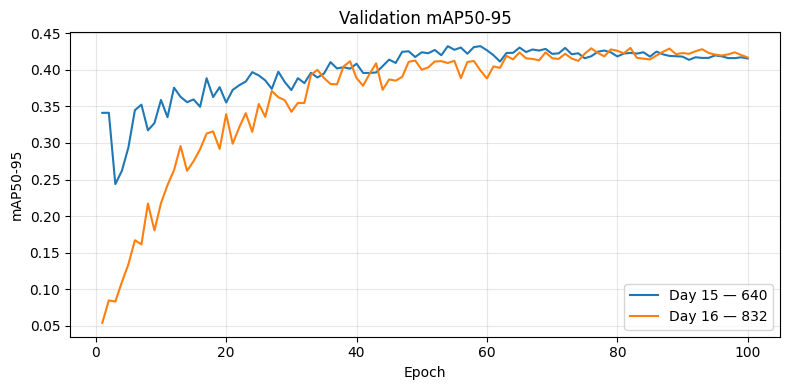

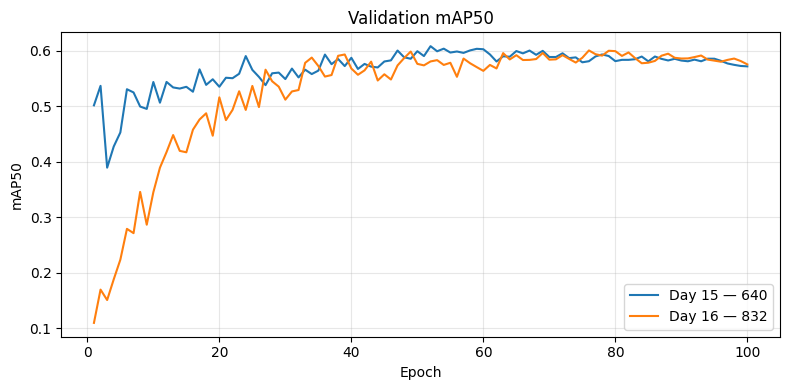

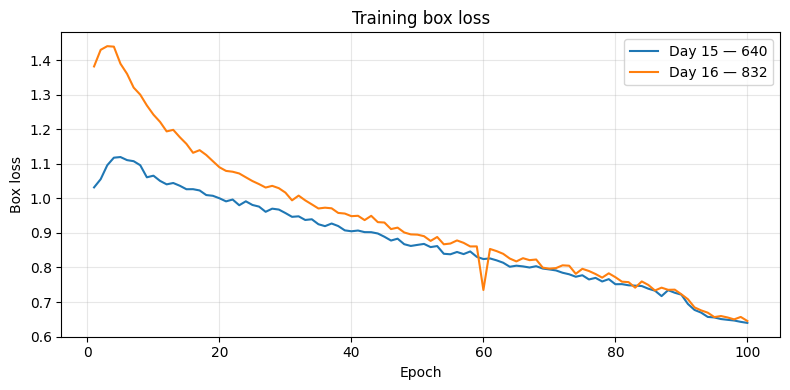

In [35]:
# Day 16.6 — Training curves
# Automatically loads the actual Day 15 and Day 16 results.csv files.

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = Path("/content/drive/MyDrive/INTERNSHIPWORK/yolo_runs")


# ---------------------------------------------------------
# Find results.csv files
# ---------------------------------------------------------

day15_files = list(
    PROJECT_DIR.glob("day15_yolov8n_baseline*/results.csv")
)

day16_files = list(
    PROJECT_DIR.glob("day16_yolov8n_img832*/results.csv")
)


if not day15_files:
    raise FileNotFoundError("Day 15 results.csv not found.")

if not day16_files:
    raise FileNotFoundError("Day 16 results.csv not found.")


# ---------------------------------------------------------
# Select the run with the highest completed epoch
# ---------------------------------------------------------

def select_longest_run(files):

    runs = []

    for csv_file in files:

        df = pd.read_csv(csv_file)

        if "epoch" in df.columns:
            last_epoch = df["epoch"].max()
            runs.append((last_epoch, csv_file))

    if not runs:
        raise FileNotFoundError("No valid results.csv found.")

    runs.sort(key=lambda x: x[0], reverse=True)

    return runs[0][1]


day15_csv = select_longest_run(day15_files)
day16_csv = select_longest_run(day16_files)


# ---------------------------------------------------------
# Load metrics
# ---------------------------------------------------------

r15 = pd.read_csv(day15_csv)
r16 = pd.read_csv(day16_csv)


print("Day 15:", day15_csv)
print("Day 16:", day16_csv)

print("\nDay 15 epochs:",
      r15["epoch"].min(), "to", r15["epoch"].max())

print("Day 16 epochs:",
      r16["epoch"].min(), "to", r16["epoch"].max())


# ---------------------------------------------------------
# Plot function
# ---------------------------------------------------------

def plot_curve(metric, ylabel, title):

    plt.figure(figsize=(8, 4))

    if metric in r15.columns:
        plt.plot(
            r15["epoch"],
            r15[metric],
            label="Day 15 — 640"
        )

    if metric in r16.columns:
        plt.plot(
            r16["epoch"],
            r16[metric],
            label="Day 16 — 832"
        )

    if metric not in r15.columns and metric not in r16.columns:
        print(f"Metric not found: {metric}")
        plt.close()
        return

    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------
# Validation curves
# ---------------------------------------------------------

plot_curve(
    "metrics/mAP50-95(B)",
    "mAP50-95",
    "Validation mAP50-95"
)

plot_curve(
    "metrics/mAP50(B)",
    "mAP50",
    "Validation mAP50"
)


# ---------------------------------------------------------
# Training box loss
# ---------------------------------------------------------

plot_curve(
    "train/box_loss",
    "Box loss",
    "Training box loss"
)

In [36]:
# Day 16.7 — Model size and inference-time measurement

from pathlib import Path
import time
from ultralytics import YOLO

PROJECT_DIR = Path("/content/drive/MyDrive/INTERNSHIPWORK/yolo_runs")


# ---------------------------------------------------------
# Find Day 16 results.csv
# ---------------------------------------------------------

day16_files = list(
    PROJECT_DIR.glob("day16_yolov8n_img832*/results.csv")
)

if not day16_files:
    raise FileNotFoundError(
        "No Day 16 results.csv found."
    )


# ---------------------------------------------------------
# Select the Day 16 run with highest epoch
# ---------------------------------------------------------

def select_longest_run(files):

    runs = []

    for csv_file in files:

        df = pd.read_csv(csv_file)

        if "epoch" in df.columns:
            runs.append(
                (df["epoch"].max(), csv_file)
            )

    if not runs:
        raise FileNotFoundError(
            "No valid Day 16 results.csv found."
        )

    runs.sort(
        key=lambda x: x[0],
        reverse=True
    )

    return runs[0][1]


day16_csv = select_longest_run(day16_files)

# The results.csv parent is the actual Day 16 run directory
day16_run_dir = day16_csv.parent

best16_path = day16_run_dir / "weights" / "best.pt"


print("Selected Day 16 run:")
print(day16_run_dir)

print("\nBest checkpoint:")
print(best16_path)


if not best16_path.exists():
    raise FileNotFoundError(
        f"Day 16 best.pt not found:\n{best16_path}"
    )


# ---------------------------------------------------------
# Load model
# ---------------------------------------------------------

best16_model = YOLO(str(best16_path))


# ---------------------------------------------------------
# Model size
# ---------------------------------------------------------

params = sum(
    p.numel()
    for p in best16_model.model.parameters()
)

size_mb = best16_path.stat().st_size / (1024 ** 2)


print("\n===================================")
print("DAY 16 MODEL INFORMATION")
print("===================================")

print(f"Model parameters: {params:,}")
print(f"best.pt size: {size_mb:.2f} MB")

Selected Day 16 run:
/content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day16_yolov8n_img832-28

Best checkpoint:
/content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day16_yolov8n_img832-28/weights/best.pt

DAY 16 MODEL INFORMATION
Model parameters: 3,012,408
best.pt size: 5.98 MB


In [37]:
# Day 16.7 — Inference time on validation images

import yaml
from pathlib import Path
import time

# ---------------------------------------------------------
# Read data.yaml
# ---------------------------------------------------------

with open(DATA_YAML, "r") as f:
    data_config = yaml.safe_load(f)

val_source = data_config.get("val")

print("YAML validation source:")
print(val_source)


# ---------------------------------------------------------
# Resolve validation path
# ---------------------------------------------------------

yaml_dir = Path(DATA_YAML).parent

val_path = Path(str(val_source))


# If relative, first try relative to data.yaml
if not val_path.is_absolute():
    val_path = yaml_dir / val_path


val_path = val_path.resolve()


print("\nResolved validation path:")
print(val_path)


if not val_path.exists():
    raise FileNotFoundError(
        f"\nValidation path does not exist:\n{val_path}\n\n"
        "Check the val: path inside data.yaml."
    )


# ---------------------------------------------------------
# Measure prediction time
# ---------------------------------------------------------

start = time.perf_counter()

timed_results = best16_model.predict(
    source=str(val_path),
    imgsz=832,
    save=False,
    verbose=False
)

elapsed = time.perf_counter() - start


n_pred_images = len(timed_results)


print("\n===================================")
print("INFERENCE TIME")
print("===================================")

print(f"Images processed: {n_pred_images}")
print(f"Total prediction time: {elapsed:.3f} seconds")

if n_pred_images > 0:

    avg_time_ms = (
        elapsed / n_pred_images * 1000
    )

    fps = n_pred_images / elapsed

    print(
        f"Average prediction time/image: "
        f"{avg_time_ms:.2f} ms"
    )

    print(
        f"Approximate FPS: {fps:.2f}"
    )

YAML validation source:
images/val

Resolved validation path:
/content/TrashCAN_YOLO_Dataset_V1/images/val
WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs


INFERENCE TIME
Images processed: 1204
Total prediction time: 12.764 seconds
Average prediction time/image: 10.60 ms
Approximate FPS: 94.33


In [38]:
# Day 16.8 — Save validation predictions

PRED_DIR_DAY16 = (
    day16_run_dir / "validation_predictions"
)

print("Saving predictions to:")
print(PRED_DIR_DAY16)


pred_results = best16_model.predict(
    source=str(val_path),
    imgsz=832,
    conf=0.25,
    save=True,
    project=str(day16_run_dir),
    name="validation_predictions",
    verbose=False
)


print("\nDay 16 validation predictions saved to:")
print(PRED_DIR_DAY16)

Saving predictions to:
/content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day16_yolov8n_img832-28/validation_predictions
WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

Results saved to /content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day16_yolov8n_img832-28/validation_predictions

Day 16 validation predictions saved to:
/content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day16_yolov8n_img832-28/validation_predictions


In [39]:
# Day 16.9 — Compact Day 15 vs Day 16 comparison

import pandas as pd
from pathlib import Path

PROJECT_DIR = Path(
    "/content/drive/MyDrive/INTERNSHIPWORK/yolo_runs"
)


# ---------------------------------------------------------
# Find results
# ---------------------------------------------------------

day15_files = list(
    PROJECT_DIR.glob(
        "day15_yolov8n_baseline*/results.csv"
    )
)

day16_files = list(
    PROJECT_DIR.glob(
        "day16_yolov8n_img832*/results.csv"
    )
)


# ---------------------------------------------------------
# Select longest completed run
# ---------------------------------------------------------

def select_longest_run(files):

    runs = []

    for csv_file in files:

        df = pd.read_csv(csv_file)

        if "epoch" in df.columns:

            runs.append(
                (df["epoch"].max(), csv_file)
            )

    if not runs:
        raise FileNotFoundError(
            "No valid results.csv files found."
        )

    runs.sort(
        key=lambda x: x[0],
        reverse=True
    )

    return runs[0][1]


day15_csv = select_longest_run(day15_files)
day16_csv = select_longest_run(day16_files)


r15 = pd.read_csv(day15_csv)
r16 = pd.read_csv(day16_csv)


# ---------------------------------------------------------
# Comparison table
# ---------------------------------------------------------

day16_comparison = pd.DataFrame({

    "Metric": [
        "mAP50",
        "mAP50-95",
        "Precision",
        "Recall"
    ],

    "Day 15 — 640": [
        r15["metrics/mAP50(B)"].max(),
        r15["metrics/mAP50-95(B)"].max(),
        r15["metrics/precision(B)"].max(),
        r15["metrics/recall(B)"].max()
    ],

    "Day 16 — 832": [
        r16["metrics/mAP50(B)"].max(),
        r16["metrics/mAP50-95(B)"].max(),
        r16["metrics/precision(B)"].max(),
        r16["metrics/recall(B)"].max()
    ]
})


display(day16_comparison)


# ---------------------------------------------------------
# Run information
# ---------------------------------------------------------

print("\nDay 15 results:")
print(day15_csv)

print("\nDay 16 results:")
print(day16_csv)

print("\nDay 15 epochs:",
      r15["epoch"].min(),
      "to",
      r15["epoch"].max())

print("Day 16 epochs:",
      r16["epoch"].min(),
      "to",
      r16["epoch"].max())


# ---------------------------------------------------------
# Interpretation
# ---------------------------------------------------------

print("\nInterpretation:")
print(
    "Day 16 evaluated the YOLOv8n detector at "
    "832×832 resolution using the same general "
    "dataset comparison."
)

print(
    "The recorded validation metrics should be "
    "compared together with model size, inference "
    "time, and prediction behaviour."
)

print(
    "No improvement should be claimed unless the "
    "recorded outputs support it."
)

,Metric,Day 15 — 640,Day 16 — 832
0,mAP50,0.60804,0.60035
1,mAP50-95,0.43221,0.42982
2,Precision,0.81889,0.79522
3,Recall,0.60639,0.59929



Day 15 results:
/content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day15_yolov8n_baseline-5/results.csv

Day 16 results:
/content/drive/MyDrive/INTERNSHIPWORK/yolo_runs/day16_yolov8n_img832-28/results.csv

Day 15 epochs: 1 to 100
Day 16 epochs: 1 to 100

Interpretation:
Day 16 evaluated the YOLOv8n detector at 832×832 resolution using the same general dataset comparison.
The recorded validation metrics should be compared together with model size, inference time, and prediction behaviour.
No improvement should be claimed unless the recorded outputs support it.
